In [1]:
import sys
sys.path.append("..")

from source.policy import HeuristicPolicy, NeuralPolicy
from source.simulation import rollout_trajectory, sample_initial_state
from source.stochastic_processes import make_price_function
from source.system import SystemParams
from source.utils import read_csv

import torch

In [2]:
global_seed = 123

device = torch.device("cpu")

params = SystemParams()

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

next_price_fn = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

S0 = sample_initial_state(
    batch_size=1000,
    params=params,
    device=device,
    seed=global_seed
)

policy = HeuristicPolicy()

t_hist, S_hist, endog_hist, u_hist, A_hist, B_hist, c_hist, J_episode = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_fn,
    lambda_cost=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

In [3]:
results = {}

results["heuristic"] = {
    "t_hist": t_hist,
    "S_hist": S_hist,
    "endog_hist": endog_hist,
    "u_hist": u_hist,
    "A_hist": A_hist,
    "B_hist": B_hist,
    "c_hist": c_hist,
    "J_episode": J_episode
}

In [4]:
from source.diagnostics import check_energy_balance

check_energy_balance(endog_hist, params.dt)

{'max_abs_error': 0.0,
 'mean_abs_error': 0.0,
 'mean_Ub': 34.942161560058594,
 'max_Ub': 432.0}

In [5]:
from source.plotting import *

import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

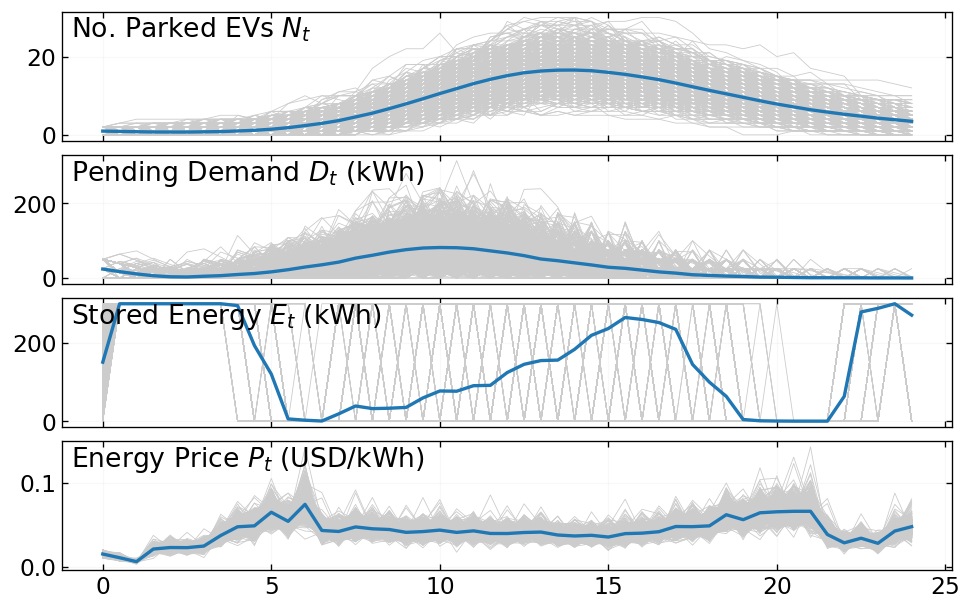

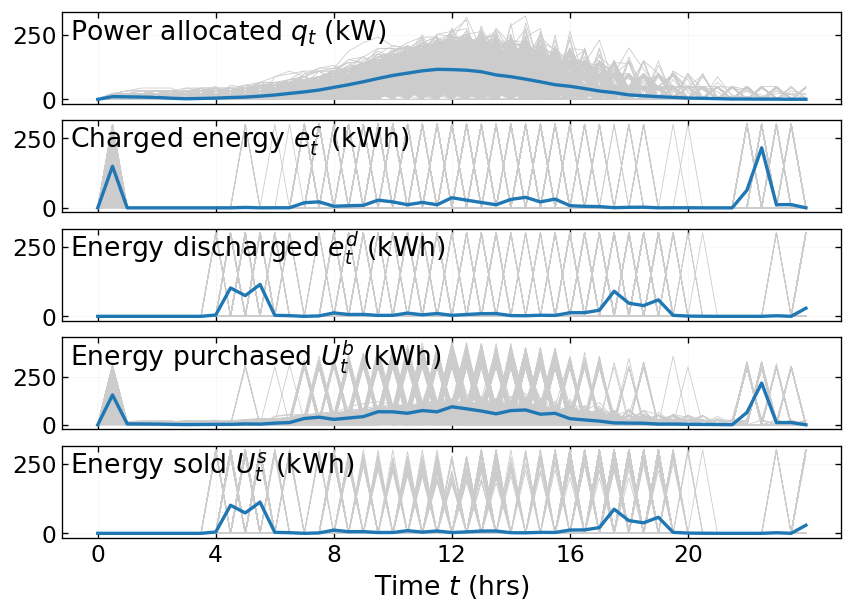

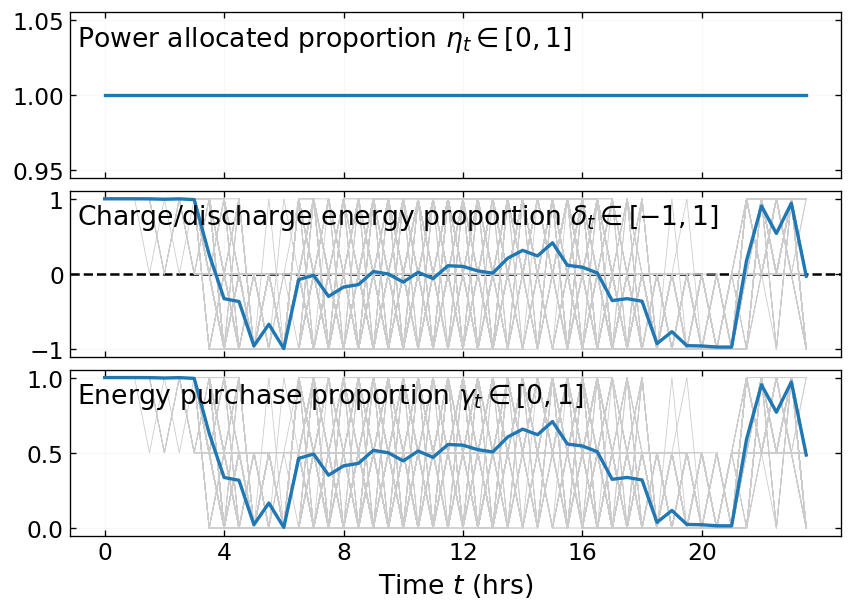

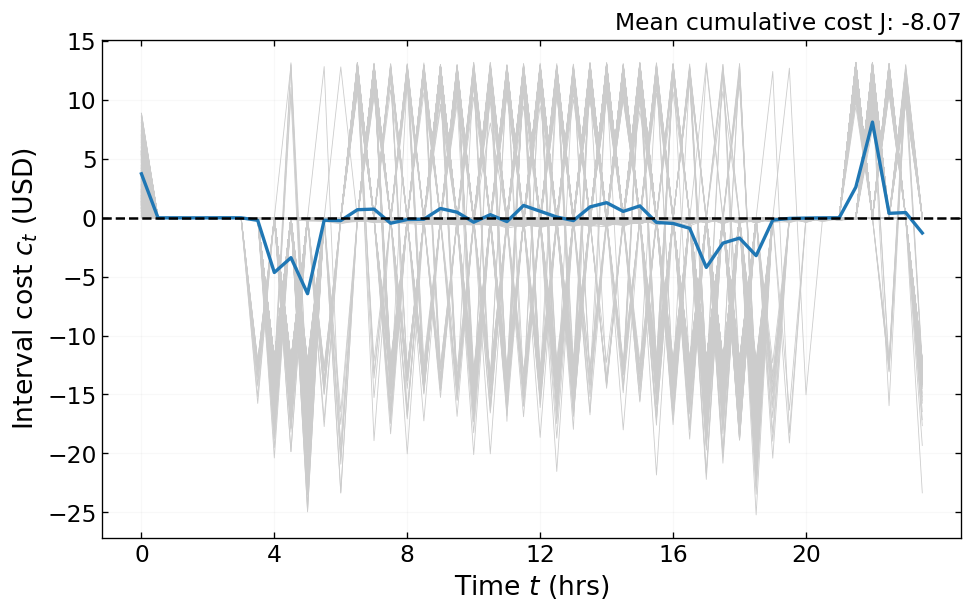

In [6]:
plot_state_trajectories(t_hist, S_hist)
plot_endogenous_trajectories(t_hist, endog_hist)
plot_control_trajectories(t_hist, u_hist)
plot_cost_trajectories(t_hist, c_hist, J_episode)

In [7]:
device = torch.device("cpu")

params = SystemParams()

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

next_price_fn = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

S0 = sample_initial_state(
    batch_size=1000,
    params=params,
    device=device,
    seed=global_seed
)

policy = NeuralPolicy()

t_hist, S_hist, endog_hist, u_hist, A_hist, B_hist, c_hist, J_episode = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_fn,
    lambda_cost=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

In [8]:
results["untrained"] = {
    "t_hist": t_hist,
    "S_hist": S_hist,
    "endog_hist": endog_hist,
    "u_hist": u_hist,
    "A_hist": A_hist,
    "B_hist": B_hist,
    "c_hist": c_hist,
    "J_episode": J_episode
}

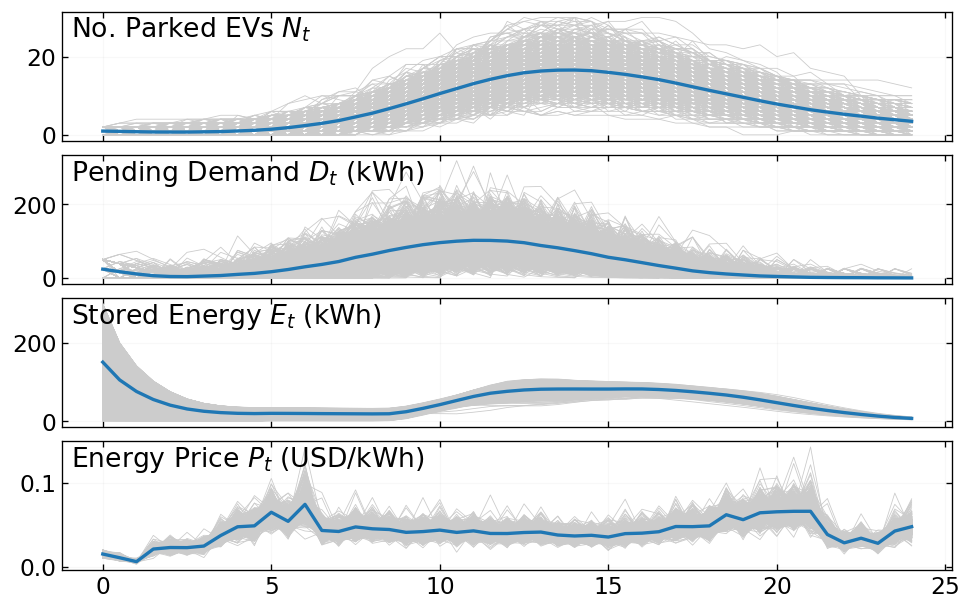

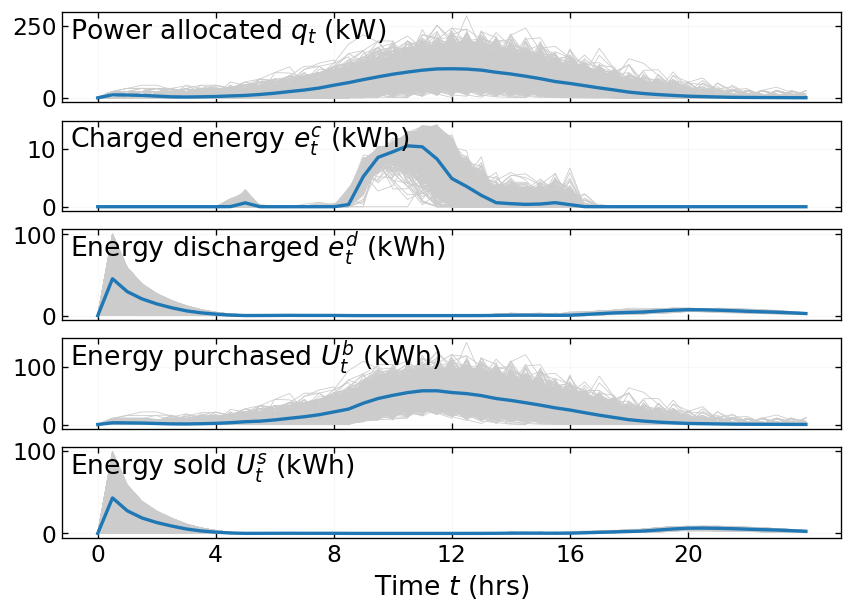

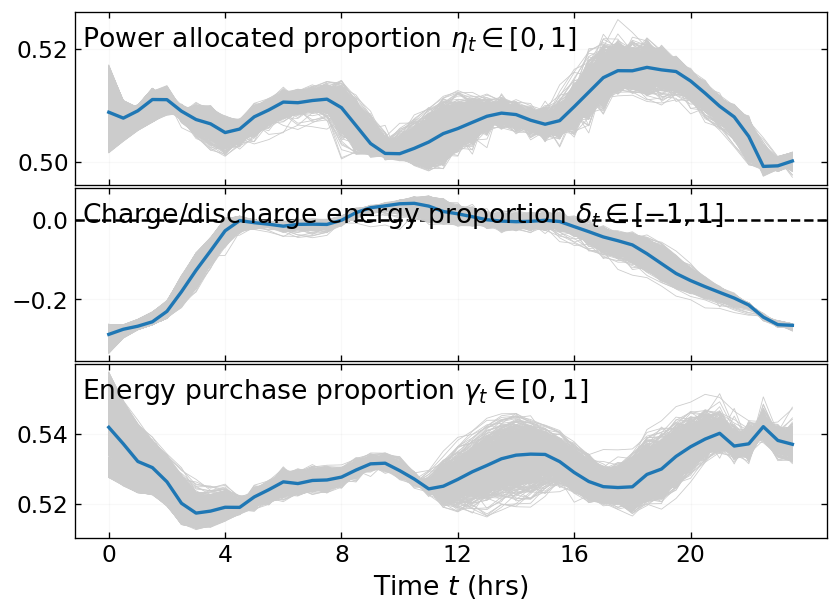

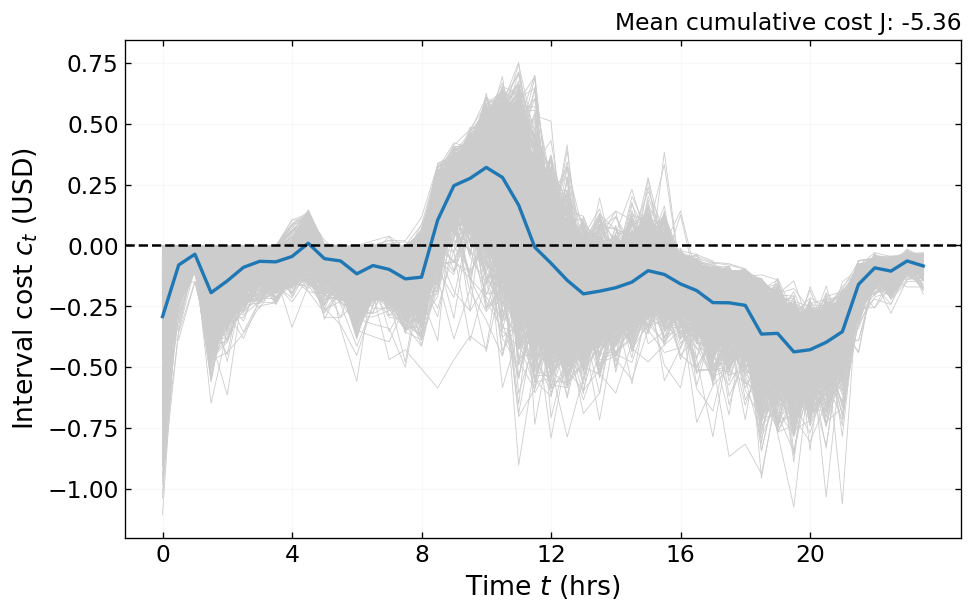

In [9]:
plot_state_trajectories(t_hist, S_hist)
plot_endogenous_trajectories(t_hist, endog_hist)
plot_control_trajectories(t_hist, u_hist)
plot_cost_trajectories(t_hist, c_hist, J_episode)

In [10]:
from source.training import train_net

EPOCHS = 20
BATCH_SIZE = 1000

DEVICE = torch.device("cpu")

params = SystemParams()

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")

price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

policy = NeuralPolicy().to(DEVICE)

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=DEVICE,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True,
    seed_base=global_seed
)

[001] J_train=-0.7605 | J_eval(det)=-1.7717
[002] J_train=-1.3786 | J_eval(det)=-2.2162
[003] J_train=-1.8111 | J_eval(det)=-2.6686
[004] J_train=-2.3344 | J_eval(det)=-3.1390
[005] J_train=-2.8553 | J_eval(det)=-3.6342
[006] J_train=-3.3983 | J_eval(det)=-4.1556
[007] J_train=-3.9093 | J_eval(det)=-4.7780
[008] J_train=-4.4064 | J_eval(det)=-5.4363
[009] J_train=-4.9086 | J_eval(det)=-6.1212
[010] J_train=-5.3473 | J_eval(det)=-6.6230
[011] J_train=-5.7998 | J_eval(det)=-6.9884
[012] J_train=-6.0648 | J_eval(det)=-7.2300
[013] J_train=-6.4208 | J_eval(det)=-7.3422
[014] J_train=-6.7226 | J_eval(det)=-7.4341
[015] J_train=-6.8978 | J_eval(det)=-7.5234
[016] J_train=-7.0923 | J_eval(det)=-7.6194
[017] J_train=-7.2896 | J_eval(det)=-7.7254
[018] J_train=-7.3619 | J_eval(det)=-7.8373
[019] J_train=-7.5796 | J_eval(det)=-7.9543
[020] J_train=-7.6348 | J_eval(det)=-8.0758

Training ready in 16.5s. Epoch: 20. Best J=-7.6348


In [16]:
next_price_fn = make_price_function(price_history, future_price, params)

S0_demo = S0_single.repeat(BATCH_SIZE, 1)

policy.load_state_dict(res["best_state"])

t_hist, S_hist, endog_hist, u_hist, A_hist, B_hist, c_hist, J_episode = rollout_trajectory(
    policy=policy,
    S0=S0_demo,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    seed=global_seed,
    device=DEVICE,
)

print(f"Demo rollout J: {J_episode:.4f}")

Demo rollout J: -7.8525


In [17]:
results["trained"] = {
    "t_hist": t_hist,
    "S_hist": S_hist,
    "endog_hist": endog_hist,
    "u_hist": u_hist,
    "A_hist": A_hist,
    "B_hist": B_hist,
    "c_hist": c_hist,
    "J_episode": J_episode
}

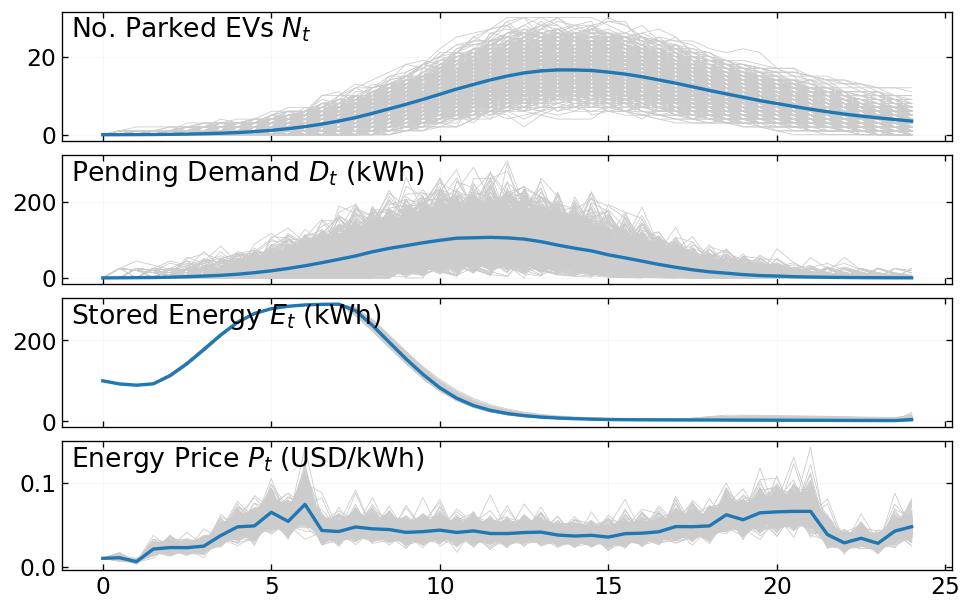

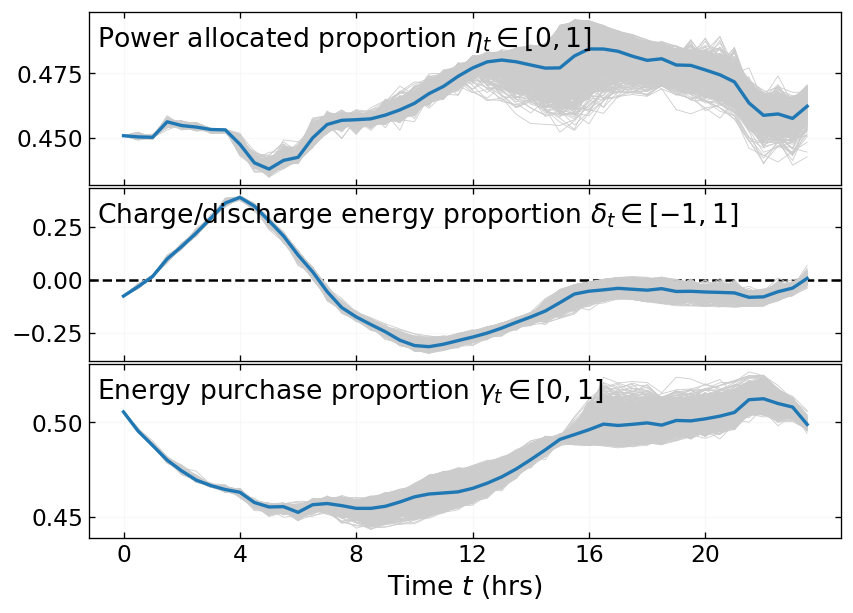

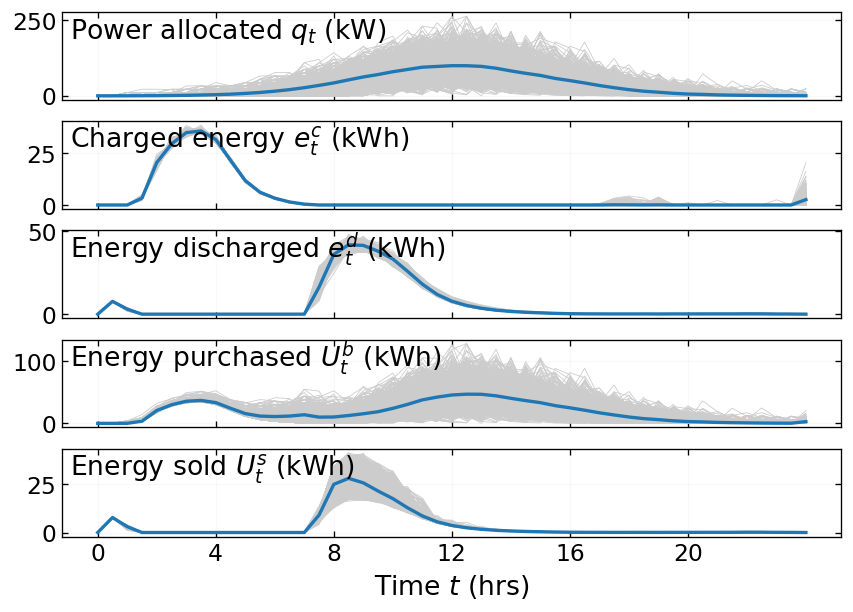

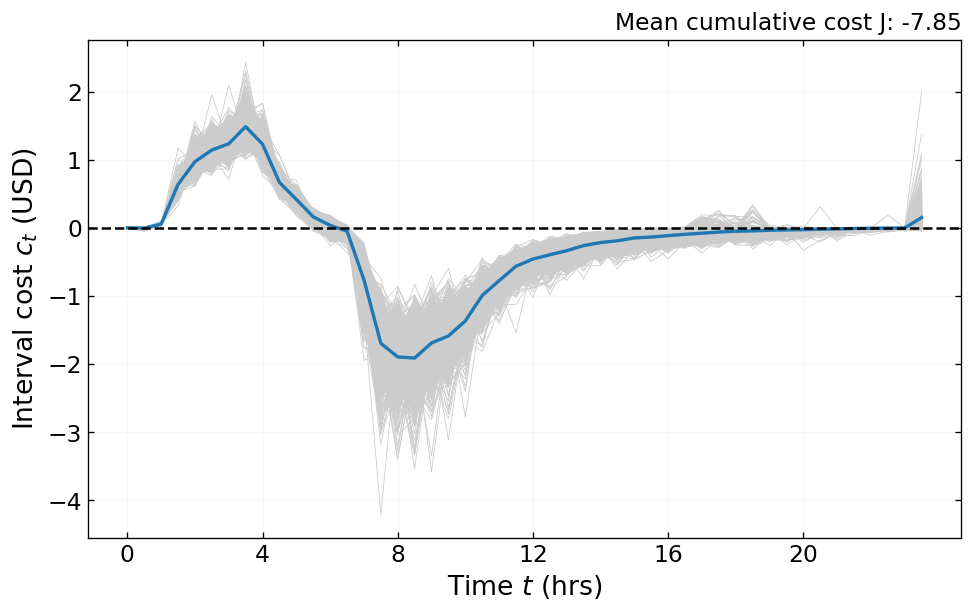

In [13]:
plot_state_trajectories(t_hist, S_hist)
plot_control_trajectories(t_hist, u_hist)
plot_endogenous_trajectories(t_hist, endog_hist)
plot_cost_trajectories(t_hist, c_hist, J_episode)

In [14]:
print("\n" + "="*60)
print("ARRIVALS (A_hist)")
print("="*60)

same = torch.allclose(
    results["untrained"]["A_hist"],
    results["heuristic"]["A_hist"]
)
max_diff = (
    results["untrained"]["A_hist"]
    - results["heuristic"]["A_hist"]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["A_hist"],
    results["trained"]["A_hist"]
)
max_diff = (
    results["untrained"]["A_hist"]
    - results["trained"]["A_hist"]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")


print("\n" + "="*60)
print("DEPARTURES (B_hist)")
print("="*60)

same = torch.allclose(
    results["untrained"]["B_hist"],
    results["heuristic"]["B_hist"]
)
max_diff = (
    results["untrained"]["B_hist"]
    - results["heuristic"]["B_hist"]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["B_hist"],
    results["trained"]["B_hist"]
)
max_diff = (
    results["untrained"]["B_hist"]
    - results["trained"]["B_hist"]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")


print("\n" + "="*60)
print("PRICE (S_hist[..., 3])")
print("="*60)

same = torch.allclose(
    results["untrained"]["S_hist"][..., 3],
    results["heuristic"]["S_hist"][..., 3]
)
max_diff = (
    results["untrained"]["S_hist"][..., 3]
    - results["heuristic"]["S_hist"][..., 3]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["S_hist"][..., 3],
    results["trained"]["S_hist"][..., 3]
)
max_diff = (
    results["untrained"]["S_hist"][..., 3]
    - results["trained"]["S_hist"][..., 3]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)

A_same = torch.allclose(
    results["untrained"]["A_hist"],
    results["trained"]["A_hist"]
)

B_same = torch.allclose(
    results["untrained"]["B_hist"],
    results["trained"]["B_hist"]
)

P_same = torch.allclose(
    results["untrained"]["S_hist"][..., 3],
    results["trained"]["S_hist"][..., 3]
)

if A_same and B_same and P_same:
    print("✅ Same stochastic scenario across policies.")
else:
    print("❌ Stochastic processes differ between policies.")
    print(f"   Arrivals equal   : {A_same}")
    print(f"   Departures equal : {B_same}")
    print(f"   Prices equal     : {P_same}")


ARRIVALS (A_hist)
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : False
Max difference         : 9.000000

DEPARTURES (B_hist)
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : False
Max difference         : 11.000000

PRICE (S_hist[..., 3])
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : False
Max difference         : 0.009994

SUMMARY
❌ Stochastic processes differ between policies.
   Arrivals equal   : False
   Departures equal : False
   Prices equal     : False
